In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Что надо сделать?
1) Преобразование сырового датафрейма в готовый за 1 функцию. (внимание на столбец индекса)
2) Функции для разметки паттернов для каждого паттерна (поглощение, молот, перевёрнутый молот, просвет в облаках/тёмные облака, основание пинцет, Бычий захват за пояс, Харами, 3 свечи, утренняя звезда) бычьи и медвежьи в 2 датафрейма. (Считай паттерн в день делать можно) Это работка не очень сложная
3) Проверка паттернов через n свеч. надо придумать 1 вариант для всех стратегий. Следует подумать какие графики и какие статистические показатели или тесты использовать.
4) Как вёдёт себя цена после открытия позиции, глянуть распределения?
5) Торговая стратегия на основе машинного обучения. Она должна максимизировать прибыль. Может быть получится придумать какой-то алгоритм. Желательно, чтобы данная оптимизация работа для всех паттернов
6) Поиск новых паттернов, которые статистически что-то показывают*

In [2]:
sber = pd.read_csv('data/SBRF.txt')

In [3]:
sber

,<TICKER>,<PER>,<DATE>,<TIME>,<OPEN>,<HIGH>,<LOW>,<CLOSE>,<VOL>
0,SBRF,1,20090111,103000,2301,2335,2301,2321,123
1,SBRF,1,20090111,103100,2321,2321,2265,2269,194
2,SBRF,1,20090111,103200,2310,2344,2310,2344,383
3,SBRF,1,20090111,103300,2344,2346,2333,2333,67
4,SBRF,1,20090111,103400,2334,2334,2334,2334,2
...,...,...,...,...,...,...,...,...,...
3298843,SBRF,1,20250630,234400,29851,29851,29845,29845,28
3298844,SBRF,1,20250630,234500,29843,29845,29829,29845,39
3298845,SBRF,1,20250630,234700,29828,29828,29827,29827,3
3298846,SBRF,1,20250630,234800,29832,29841,29805,29815,262


In [4]:
def good_dataframe(data):
  """Преобразует сырые рыночные данные в чистый DataFrame с правильными типами и индексом времени
    
    Подготавливает данные для технического анализа.
    
    Args:
        data (pd.DataFrame): Исходный DataFrame с рыночными данными, содержащий столбцы:
            ['<TICKER>', '<PER>', '<DATE>', '<TIME>', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<VOL>']
            
    Returns:
        tuple: Возвращает кортеж из двух DataFrame:
            - Основной DataFrame с индексом времени
            - Копия DataFrame для безопасного резервирования
            
    Processing Logic:
        1. Удаление избыточных столбцов
        2. Переименование столбцов в human-friendly формат
        3. Преобразование типов данных
        4. Создание правильного временного индекса
    """
  # 1. Удаляем ненужные столбцы (тикер и период не нужны для анализа)
  data.drop(['<TICKER>', '<PER>'], inplace=True, axis=1)
    
  # 2. Переименовываем столбцы для удобства работы
  data.columns = ['date', 'time', 'open', 'high', 'low', 'close', 'volume']
    
  # 3. Преобразуем дату из формата YYYYMMDD в datetime
  data['date'] = pd.to_datetime(data['date'], format='%Y%m%d')
    
  # 4. Обрабатываем время (HHMMSS -> datetime.time)
  data['time'] = pd.to_datetime(data['time'], format='%H%M%S').dt.time
    
  # 5. Комбинируем дату и время в единую метку времени
  data['time'] = pd.to_datetime(
        data['date'].astype('str') + ' ' + data['time'].astype('str'))
    
  # 6. Удаляем отдельный столбец даты (теперь он в индексе)
  data.drop(['date'], inplace=True, axis=1)
    
  # 7. Устанавливаем комбинированную метку времени как индекс
  data = data.set_index('time')
    
  # 8. Создаем резервную копию для безопасного использования
  data_copy = data.copy()
  
  return data, data_copy


In [5]:
sber_df, sber_df_copy = good_dataframe(sber)

In [6]:
sber_df

,open,high,low,close,volume
time,,,,,
2009-01-11 10:30:00,2301,2335,2301,2321,123
2009-01-11 10:31:00,2321,2321,2265,2269,194
2009-01-11 10:32:00,2310,2344,2310,2344,383
2009-01-11 10:33:00,2344,2346,2333,2333,67
2009-01-11 10:34:00,2334,2334,2334,2334,2
...,...,...,...,...,...
2025-06-30 23:44:00,29851,29851,29845,29845,28
2025-06-30 23:45:00,29843,29845,29829,29845,39
2025-06-30 23:47:00,29828,29828,29827,29827,3


In [7]:
def new_timeframe(data, timeframe):
    """Преобразует минутные данные (1М) в указанный временной интервал, сохраняя структуру OHLCV-данных.
    
    Использует принципы агрегации свечных данных:
    - Open - первое значение периода
    - High - максимум периода
    - Low - минимум периода
    - Close - последнее значение периода
    - Volume - сумма объема за период

    Args:
        data (pd.DataFrame): Исходный DataFrame с 1-минутными данными, 
                            должен содержать колонки ['open', 'high', 'low', 'close', 'volume']
                            и иметь DateTimeIndex
        timeframe (str): Желаемый таймфрейм из списка доступных:
                        ['5 min', '15 min', '30 min', '1h', '2h', '4h', 'D']

    Returns:
        pd.DataFrame: Новый DataFrame с преобразованными данными в указанном таймфрейме
        
    Raises:
        ValueError: Если передан неподдерживаемый timeframe
    """
    dict_tf = {'5 min' : '5min', '15 min' : '15min', '30 min' : '30min',
               '1h' : '1h', '2h' : '2h', '4h' : '4h', 'D' : 'D'}

    return_data = data.resample(dict_tf[timeframe]).agg({
            'open': 'first',
            'high': 'max',
            'low': 'min',
            'close': 'last',
            'volume': 'sum'
        }).dropna()
    
    return return_data



# Функции для детекции паттернов "Бычье поглощение" и "Медвежье поглощение"

## 📋 Описание
Функция принимает на вход датафрейм с финансовыми данными и возвращает отдельный датафрейм, содержащих размеченную формацию:
- **Бычье поглощение** (Bullish Engulfing Pattern)
- **Медвежье поглощение** (Bearish Engulfing Pattern)

## 🎯 Назначение
Автоматическое обнаружение разворотных свечных паттернов для технического анализа финансовых инструментов.

In [ ]:
sber_4h = new_timeframe(sber_df, '1h')
sber_4h = sber_4h.reset_index()

In [9]:
sber_4h

,time,open,high,low,close,volume,body
0,2009-01-11 10:00:00,2301.0,2380.0,2265.0,2361.0,7797,60.0
1,2009-01-11 11:00:00,2366.0,2369.0,2324.0,2346.0,5669,-20.0
2,2009-01-11 12:00:00,2346.0,2354.0,2328.0,2339.0,2264,-7.0
3,2009-01-11 13:00:00,2335.0,2346.0,2330.0,2338.0,876,3.0
4,2009-01-11 14:00:00,2339.0,2342.0,2333.0,2334.0,860,-5.0
...,...,...,...,...,...,...,...
58520,2025-06-30 19:00:00,29871.0,29892.0,29830.0,29859.0,1093,-12.0
58521,2025-06-30 20:00:00,29858.0,29879.0,29847.0,29857.0,756,-1.0
58522,2025-06-30 21:00:00,29857.0,29876.0,29854.0,29865.0,1059,8.0
58523,2025-06-30 22:00:00,29870.0,29874.0,29834.0,29838.0,802,-32.0


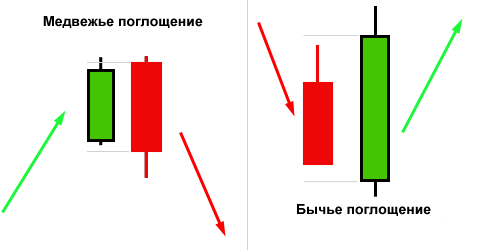

In [10]:
def detection_bullish_engulfing_pattern(data):
    data['pattern'] = 0
    
    # Бычье поглощение 
    data_bull = data.copy()
    for i in range(1, len(data_bull)):
        previous_row = data_bull.iloc[i - 1]
        current_row = data_bull.iloc[i]
    
        if (previous_row['body'] < 0 and current_row['body'] > 0) and (previous_row['open'] < current_row['close']) and (previous_row['close'] > current_row['open']):
            data_bull.loc[i-1, 'pattern'] = 1
            data_bull.loc[i, 'pattern'] = 1
            
    return data_bull
            

    

In [11]:
def detection_bearish_engulfing_pattern(data):
    data['pattern'] = 0
    
    # Медвежье поглощение
    data_bear = data.copy()
    for i in range(1, len(data_bear)):
        previous_row = data_bear.iloc[i - 1]
        current_row = data_bear.iloc[i]
    
        if (previous_row['body'] > 0 and current_row['body'] < 0) and (previous_row['open'] > current_row['close']) and (previous_row['close'] < current_row['open']):
            data_bear.loc[i-1, 'pattern'] = -1
            data_bear.loc[i, 'pattern'] = -1
            
    return data_bear

In [12]:
sber_4h_bull = detection_bullish_engulfing_pattern(sber_4h)
sber_4h_bear = detection_bearish_engulfing_pattern(sber_4h)

In [13]:
sber_4h_bull

,time,open,high,low,close,volume,body,pattern
0,2009-01-11 10:00:00,2301.0,2380.0,2265.0,2361.0,7797,60.0,0
1,2009-01-11 11:00:00,2366.0,2369.0,2324.0,2346.0,5669,-20.0,0
2,2009-01-11 12:00:00,2346.0,2354.0,2328.0,2339.0,2264,-7.0,0
3,2009-01-11 13:00:00,2335.0,2346.0,2330.0,2338.0,876,3.0,0
4,2009-01-11 14:00:00,2339.0,2342.0,2333.0,2334.0,860,-5.0,0
...,...,...,...,...,...,...,...,...
58520,2025-06-30 19:00:00,29871.0,29892.0,29830.0,29859.0,1093,-12.0,0
58521,2025-06-30 20:00:00,29858.0,29879.0,29847.0,29857.0,756,-1.0,0
58522,2025-06-30 21:00:00,29857.0,29876.0,29854.0,29865.0,1059,8.0,0
58523,2025-06-30 22:00:00,29870.0,29874.0,29834.0,29838.0,802,-32.0,0


In [18]:
sber_4h_bull[sber_4h_bull['pattern'] == 1]

,time,open,high,low,close,volume,body,pattern
33,2009-01-13 15:00:00,2213.0,2215.0,2200.0,2208.0,12589,-5.0,1
34,2009-01-13 16:00:00,2207.0,2226.0,2206.0,2224.0,9114,17.0,1
57,2009-01-15 11:00:00,2091.0,2136.0,2032.0,2060.0,30642,-31.0,1
58,2009-01-15 12:00:00,2058.0,2096.0,2037.0,2092.0,17290,34.0,1
294,2009-02-09 10:00:00,1611.0,1615.0,1568.0,1593.0,37694,-18.0,1
...,...,...,...,...,...,...,...,...
58508,2025-06-27 22:00:00,29666.0,29704.0,29659.0,29696.0,2126,30.0,1
58513,2025-06-30 12:00:00,29687.0,29775.0,29657.0,29664.0,14307,-23.0,1
58514,2025-06-30 13:00:00,29658.0,29870.0,29646.0,29822.0,15173,164.0,1
58517,2025-06-30 16:00:00,29839.0,29865.0,29793.0,29818.0,4768,-21.0,1


# Анализ стратегии: кумулятивная прибыль, распределение и основные статистические признаки

## 📋 Описание
Данная аналитическая функция предназначена для оценки эффективности торговой стратегии, основываясь на временных данных о доходности. Она предоставляет комплексное понимание с помощью визуализации и статистических метрик.

## 🎯 Назначение
Помогает трейдерам и аналитикам обнаружить сильные стороны и слабые места стратегии, выявить распределение прибыли и рассчитать ключевые показатели, такие как среднее, медиана, стандартное отклонение и коэффициент Шарпа, что способствует принятию обоснованных решений для дальнейшей оптимизации.

## 🔧 Что делает функция:
- Вычисляет кумулятивную прибыль по вашей стратегии для оценки общего результата со временем.
- Строит гистограмму распределения доходностей, позволяя визуально оценить их характер.
- Рассчитывает важные статистические метрики, такие как среднее, медиана, стандартное отклонение, асимметрия, эксцесс, коэффициент Шарпа, максимальную и минимальную прибыль, а также суммарную прибыль.

## 📈 Визуализация
Функция автоматически отображает график распределения доходности, чтобы оценить риск и вероятность значительных потерь или прибыли.

## ⚙️ Использование
Данная функция является мощным инструментом для анализа эффективности алгоритмических стратегий, подпитывая принятие решений данными и статистикой.

---

,Среднее,Медиана,Стандартное отклонение,Win rate
Группа,,,,
Все сделки,34.10,26.79,675.08,-
Убыточные сделки,-428.39,-275.35,545.08,47.7
Прибыльные сделки,455.86,319.80,476.89,52.3


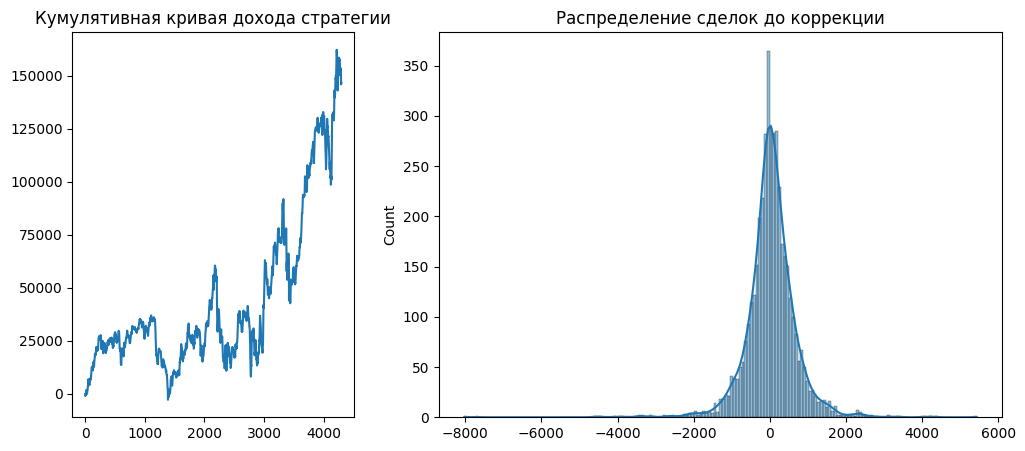

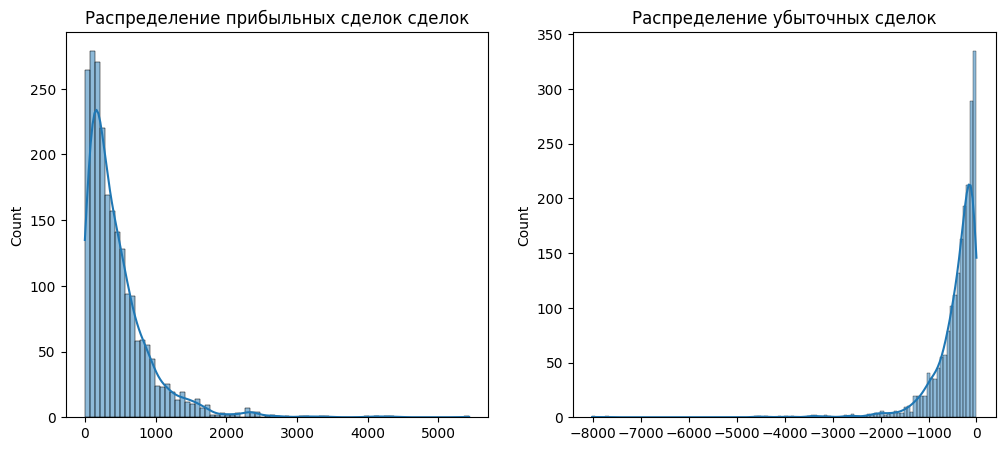

In [14]:
def statistic_strategy_bullish(data, N=1, commision=0.0005, slippage=0.0005):
    # Создаём список в котором будем хранить данные о стратегии
    lst_all = []
    for i in range(len(data) - (N + 1)):
        over_n_candle_row = data.iloc[i + (N + 1)]
        if data.loc[i, 'pattern'] == 1:
            next_row = data.iloc[i + 2]
            entry_price = next_row['open'] * (1 + slippage) # Цена входа
            exit_price = over_n_candle_row['close'] * (1 - slippage) # Цена выхода
            profit = exit_price - entry_price
            if profit > 0:
                profit_net = profit * (1 - commision)
            else:
                profit_net = profit * (1 + commision)
            lst_all.append(profit_net)
    # Посчитаем кумулятивную сумму
    cum_sum = np.cumsum(lst_all)
    
    # Создадим отдельно списки для убыточных сделок и прибыльных сделок
    lst_loss = [i for i in lst_all if i < 0]
    lst_profit = [i for i in lst_all if i > 0]
    
    # Рассчитаем все необходимые статистические показатели:
    
    mean_all = round(np.mean(lst_all), 2)       # Среднее для всех сделок
    mean_loss = round(np.mean(lst_loss), 2)     # Среднее для убыточных сделок
    mean_profit = round(np.mean(lst_profit), 2) # Среднее для прибыльных сделок

    median_all = round(np.median(lst_all), 2)       # Медиана для всех сделок
    median_loss = round(np.median(lst_loss), 2)     # Медиана для убыточных сделок
    median_profit = round(np.median(lst_profit), 2) # Медиана для прибыльных сделок

    std_all = round(np.std(lst_all), 2)         # Стандартное отклонение для всех сделок
    std_loss = round(np.std(lst_loss), 2)       # Стандартное отклонение для убыточных сделок
    std_profit = round(np.std(lst_profit), 2)   # Стандартное отклонение для прибыльных сделок
    
    percent_loss = round(len(lst_loss) / len(lst_all) * 100, 2)
    percent_profit = round(len(lst_profit) / len(lst_all) * 100, 2)
    
    # Построим 2 графика 
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 2]})
    
    # 1 график
    lineplot = sns.lineplot(cum_sum, ax=axes[0])
    lineplot.set_title('Кумулятивная кривая дохода стратегии')
    
    # 2 график
    histplot = sns.histplot(lst_all, kde=True, ax=axes[1])
    histplot.set_title('Распределение сделок до коррекции')

    # Создадим датафрейм для удобной визуализации
    data = {
    'Группа': ['Все сделки', 'Убыточные сделки', 'Прибыльные сделки'],
    'Среднее': [mean_all, mean_loss, mean_profit],
    'Медиана': [median_all, median_loss, median_profit],
    'Стандартное отклонение': [std_all, std_loss, std_profit],
    'Win rate': ['-', percent_loss, percent_profit]
    }
    data_frame = pd.DataFrame(data)
    display(data_frame.set_index('Группа'))

    
    # Построим распределения прибылей и убытков
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1 график
    histplot_1 = sns.histplot(lst_profit, kde=True, ax=axes[0])
    histplot_1.set_title('Распределение прибыльных сделок сделок')
    
    # 2 график
    histplot_2 = sns.histplot(lst_loss, kde=True, ax=axes[1])
    histplot_2.set_title('Распределение убыточных сделок')



lst_all = statistic_strategy_bullish(sber_4h_bull, N=50)

А что если попытаться представить, что у нас стоит упрощенный стоп-лосс. Мы не будем учитывать убытки, которые больше определенного уровня, заменяя их на какой-то фиксированный стоп. В таком случае мы сможем избавиться от толстых хвостов в убытках. Данный метод не совсем корректен, так как бывают случаи, когда цена падает до какого-то отрицательного значения, однако потом возвращается и даже может принести прибыль, однако чаще всего цена падает, не возвращаясь. 
Понимание как движется цена после входа может дать достаточно много полезной информации, займёмся этим позже.
Надо учитывать, что если ставить стопы очень маленькие, то может показаться, что стратегия становится прибыльной, однако мы совсем не знаем, сколько раз стоп сработает, а цена потом развернётся, поэтому со стопами в такой функции надо играться осторожно, и отсекать только хвосты 2-3 сигмы.

,Среднее,Медиана,Стандартное отклонение,Win rate
Группа,,,,
Все сделки,3.75,-1.94,408.53,-
Убыточные сделки,-269.02,-170.28,301.31,50.26
Прибыльные сделки,279.33,181.88,304.42,49.74


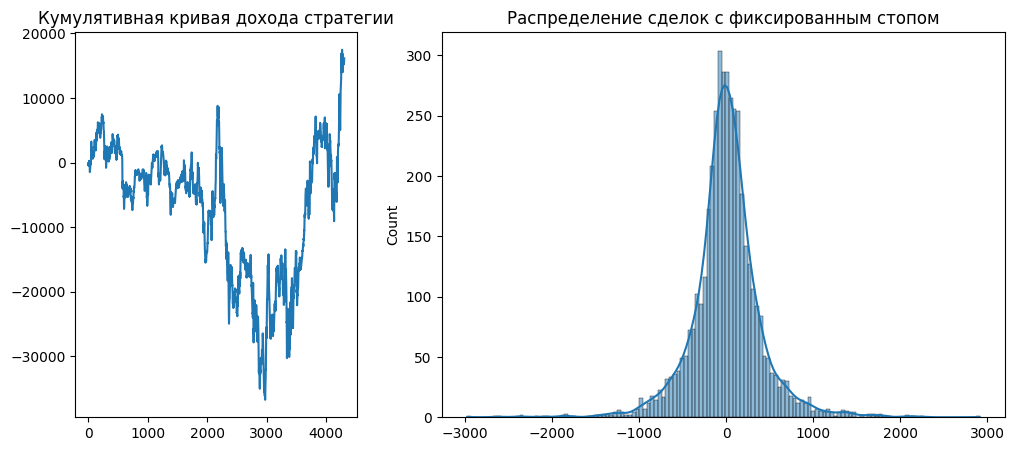

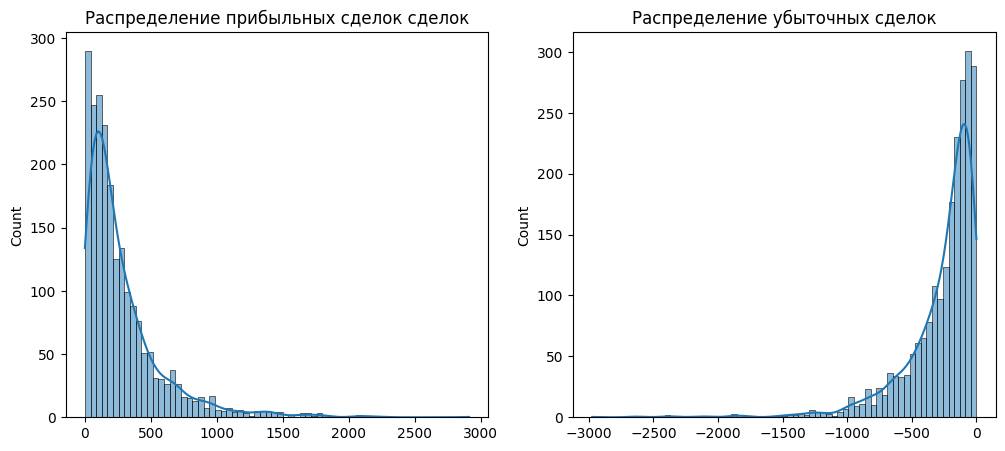

In [15]:
def statistic_strategy_bullish_stop(data, N=1, commision=0.0005, slippage=0.0005, stop=-2000):
    # Создаём список в котором будем хранить данные о стратегии
    lst_all = []
    for i in range(len(data) - (N + 1)):
        over_n_candle_row = data.iloc[i + (N + 1)]
        if data.loc[i, 'pattern'] == 1:
            next_row = data.iloc[i + 2]
            entry_price = next_row['open'] * (1 + slippage) # Цена входа
            exit_price = over_n_candle_row['close'] * (1 - slippage) # Цена выхода
            profit = exit_price - entry_price
            if profit > 0:
                profit_net = profit * (1 - commision)
            else:
                profit_net = profit * (1 + commision)
            lst_all.append(profit_net)
    
 
    for i in range(len(lst_all)):
        if lst_all[i] < stop:
            lst_all[i] = stop
                
    # Посчитаем кумулятивную сумму
    cum_sum = np.cumsum(lst_all)
    
    # Создадим отдельно списки для убыточных сделок и прибыльных сделок
    lst_loss = [i for i in lst_all if i < 0]
    lst_profit = [i for i in lst_all if i > 0]
    
    # Рассчитаем все необходимые статистические показатели:
    mean_all = round(np.mean(lst_all), 2)       # Среднее для всех сделок
    mean_loss = round(np.mean(lst_loss), 2)     # Среднее для убыточных сделок
    mean_profit = round(np.mean(lst_profit), 2) # Среднее для прибыльных сделок

    median_all = round(np.median(lst_all), 2)       # Медиана для всех сделок
    median_loss = round(np.median(lst_loss), 2)     # Медиана для убыточных сделок
    median_profit = round(np.median(lst_profit), 2) # Медиана для прибыльных сделок

    std_all = round(np.std(lst_all), 2)         # Стандартное отклонение для всех сделок
    std_loss = round(np.std(lst_loss), 2)       # Стандартное отклонение для убыточных сделок
    std_profit = round(np.std(lst_profit), 2)   # Стандартное отклонение для прибыльных сделок
    
    percent_loss = round(len(lst_loss) / len(lst_all) * 100, 2)
    percent_profit = round(len(lst_profit) / len(lst_all) * 100, 2)
    
    # Построим 2 графика 
    fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={'width_ratios': [1, 2]})
    
    # 1 график
    lineplot = sns.lineplot(cum_sum, ax=axes[0])
    lineplot.set_title('Кумулятивная кривая дохода стратегии')
    
    # 2 график
    histplot = sns.histplot(lst_all, kde=True, ax=axes[1])
    histplot.set_title('Распределение сделок с фиксированным стопом')

    # Создадим датафрейм для удобной визуализации
    data = {
    'Группа': ['Все сделки', 'Убыточные сделки', 'Прибыльные сделки'],
    'Среднее': [mean_all, mean_loss, mean_profit],
    'Медиана': [median_all, median_loss, median_profit],
    'Стандартное отклонение': [std_all, std_loss, std_profit],
    'Win rate': ['-', percent_loss, percent_profit]
    }
    data_frame = pd.DataFrame(data)
    display(data_frame.set_index('Группа'))

    
    # Построим распределения прибылей и убытков
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 1 график
    histplot_1 = sns.histplot(lst_profit, kde=True, ax=axes[0])
    histplot_1.set_title('Распределение прибыльных сделок сделок')
    
    # 2 график
    histplot_2 = sns.histplot(lst_loss, kde=True, ax=axes[1])
    histplot_2.set_title('Распределение убыточных сделок')



lst_all = statistic_strategy_bullish_stop(sber_4h_bull, N=20, stop=-4000)

# 📈 Анализ прибыльности свечных паттернов "Поглощение"

## 🎯 Цель проекта
Визуализировать эффективность торговой стратегии, основанной на свечных паттернах "Бычье поглощение", в абсолютных ценовых значениях.

## 📊 Методология
- **Анализируемый паттерн**: Бычье поглощение / Медвежье поглощение (Bullish Engulfing /Bearish Engulfing)
- **Торговая логика**: Вход на открытии следующей свечи, выход через N свечей
- **Учет издержек**: Комиссия и проскальзывание
- **Визуализация**: Кумулятивная прибыль в абсолютных ценах

## ⚙️ Параметры стратегии
```python
# Настройки стратегии
TIMEFRAME = "1H"               
HOLD_PERIOD = 1                  # Количество свечей удержания позиции
COMMISSION = 0.001               # Комиссия (0.1%)
SLIPPAGE = 0.0005                # Проскальзывание (0.05%)
